# Value-Added Database Validation and Examples (v1)

**Author:** Aaron Roodman  
**Date Created:** 2026-09-22  
**Last Modified:** 2026-09-22  
**Status:** Complete  
**Keywords:** AOS, DuckDB, telemetry, degrees of freedom, sensitivity matrix, validation  

## Description

Validation plots and worked examples for the value-added DuckDB database of per-exposure
Rubin Observatory engineering telemetry, derived quantities and recovered optical state.
The Active Optics System (AOS) keeps the telescope in focus and alignment; this database
records, for every `lsstcam` exposure, the telemetry an AOS analysis needs.

Key functionality:
1. Inventory every table and use the `column_coverage` table to read units and
   completeness straight from the database, so no column meaning has to be guessed.
2. Time-series and histogram validation plots for `visit_telemetry`, `optical_state`
   and `fam_dz`, including the two known coverage traps.
3. Identify which degree of freedom (DOF) each sensitivity-matrix block perturbed, by
   combining the block identity from the Consolidated Database (ConsDB) with the
   commanded DOF (Trim) from this database, using the Full Array Mode (FAM) triplet and
   perturbation-ladder structure of the observing pattern.

**Output:** Plots only; nothing is written to disk. Read-only throughout.

## Requirements

This notebook deliberately imports **no `rubin-work` code**, so it can be shared as-is.
It needs:

- The **LSST Science Pipelines stack** (`numpy`, `pandas`, `matplotlib`, `astropy`) — the
  `LSST` kernel on the Rubin Science Platform (RSP) provides all of these.
- **`duckdb`** — *not* currently in the stack, so install it once into your own user
  area with `pip install --user duckdb`. Version 0.10 or newer. This is the only
  dependency beyond the stack.
- **Read access to the database file** named in `DB_PATH` below.
- For the sensitivity-matrix section only, **ConsDB access** via
  `lsst.summit.utils.ConsDbClient`, which is in the stack. That section identifies which
  observing block an exposure belongs to; every other section is DuckDB-only and runs
  with no network access at all.

## Three DOF quantities that are not interchangeable

The database carries three distinct 50-element DOF vectors. Confusing them is the
easiest mistake to make here, so they are named explicitly:

| columns | name | meaning |
|---|---|---|
| `lut_dof0`–`lut_dof9` | **LUT** | Look-Up Table baseline, the open-loop gravity/thermal correction |
| `dof0`–`dof49` | **Trim** | the commanded correction on top of the LUT, as of the exposure |
| `tweak_dof0`–`tweak_dof49` | **Tweak** | the *step* applied at this exposure, `Trim_i - Trim_(i-1)` |

Only the ten hexapod LUT values are stored; the forty mirror-bending LUT values are not
columns of `visit_telemetry`.

Which to use depends on the question. Trim answers *what was commanded*, and is the right
quantity for a deliberate perturbation sequence: a commanded ladder of offsets appears
directly as a staircase of Trim values whose step size is the perturbation amplitude.
Tweak answers *what changed at this exposure*, which is what an event-by-event study of
closed-loop corrections needs. The sensitivity-matrix section below uses Trim.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-22 | Aaron Roodman | Initial version |
| 2026-09-22 | Aaron Roodman | Section 7 covers both sensitivity-matrix campaigns, reports the `seq_num` range of every ladder, and lists the repeated measurements |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Table Inventory and Units](#inventory)
5. [`visit_telemetry` Validation](#telemetry)
6. [`optical_state` and `fam_dz` Validation](#state)
7. [Sensitivity-Matrix Blocks: Which DOF Moved](#smatrix)
8. [Summary](#summary)

<a id='params'></a>
## 1. Parameters

In [1]:
# Path to the value-added database (read-only throughout this notebook).
DB_PATH = "/sdf/group/rubin/u/roodman/LSST/notebooks/rubin-work/value_added/output/aos_efd.duckdb"

# The turbulence era boundary: the four Telescope Mount Assembly top-ring sonic
# anemometers were not reporting before this day_obs, so every turb12* column is NaN.
TURB_START_DAY_OBS = 20251102

# Sensitivity-matrix blocks. The sub-variants (_0.._3) split the 20 bending modes into
# groups of five, so the regex takes the block number and ignores any suffix.
#
# The blocks are listed by number rather than taken as a range, because two block numbers
# inside the campaign's range carry no perturbation ladders at all and are deliberately
# excluded: BLOCK-T381 is the unperturbed reference_wavefront measurement, and BLOCK-T382
# is 650 detector bias frames labelled observation_reason "block-335" -- calibration data
# tagged with a campaign block number, with no sky exposure and no commanded DOF.
SMATRIX_BLOCK_RE = r"BLOCK-T(377|378|379|380|598)"

# Two campaigns, so two night ranges: the original sweep in April to June 2025
# (BLOCK-T377 to BLOCK-T380), and BLOCK-T598 "Sensitivity Matrix Repeatability" in
# August 2025, which re-measures a subset of the same DOF to test reproducibility.
SMATRIX_DAY_OBS_RANGES = [(20250415, 20250610), (20250801, 20250831)]

# ConsDB instrument schema for the block lookup in section 7.
CONSDB_SCHEMA = "cdb_lsstcam"

FIGSIZE_WIDE = (13, 4)
FIGSIZE_GRID = (13, 9)

<a id='setup'></a>
## 2. Setup & Imports

In [2]:
import re

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.time import Time

pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

print(f"duckdb version: {duckdb.__version__}")

# read_only=True matters: DuckDB takes a process-wide exclusive lock on write, which
# would block the nightly builder (and every other reader) for as long as this
# notebook's kernel stayed alive.
con = duckdb.connect(DB_PATH, read_only=True)
print(f"connected read-only to {DB_PATH}")

duckdb version: 1.5.5
connected read-only to /sdf/group/rubin/u/roodman/LSST/notebooks/rubin-work/value_added/output/aos_efd.duckdb


<a id='functions'></a>
## 3. Helper Functions

In [3]:
def q(sql, **params):
    """Run a SQL query and return the result as a `pandas.DataFrame`.

    Parameters
    ----------
    sql : `str`
        Any read-only SQL statement.
    **params
        Named parameters substituted as ``$name`` placeholders in `sql`.

    Returns
    -------
    df : `pandas.DataFrame`
        Query result, column names as in the query.
    """
    return con.execute(sql, params).df() if params else con.execute(sql).df()


def units_of(column_name):
    """Look up a column's units and provenance from the `column_coverage` table.

    Parameters
    ----------
    column_name : `str`
        A column of `visit_telemetry`.

    Returns
    -------
    info : `dict`
        Keys ``units``, ``source``, ``group_name``, ``n_non_null``. Empty dict if the
        column is not tracked (only the `visit_id` primary key is untracked).
    """
    df = q("SELECT group_name, source, units, n_non_null FROM column_coverage "
           "WHERE column_name = $c", c=column_name)
    return {} if df.empty else df.iloc[0].to_dict()


def label_for(column_name, fallback_units=""):
    """Axis label for a column: its name plus the units recorded in the database."""
    info = units_of(column_name)
    u = info.get("units", fallback_units)
    return f"{column_name} [{u}]" if u else column_name


def mjd_from_obs_start(obs_start):
    """Convert the `obs_start` timestamp column to Modified Julian Date.

    Parameters
    ----------
    obs_start : `pandas.Series`
        Exposure start times, TAI, as stored in `visit_telemetry`.

    Returns
    -------
    mjd : `numpy.ndarray`
        MJD in days. NaN where `obs_start` is missing.
    """
    t = pd.to_datetime(obs_start, utc=True, errors="coerce")
    mjd = np.full(len(t), np.nan)
    good = t.notna().to_numpy()
    if good.any():
        mjd[good] = Time(t[good].dt.tz_localize(None).to_numpy(), scale="tai").mjd
    return mjd


def plot_vs_time(ax, mjd, y, ylabel, title, s=2.0):
    """Scatter a quantity against MJD, annotating the finite fraction."""
    good = np.isfinite(mjd) & np.isfinite(y)
    ax.scatter(mjd[good], y[good], s=s, alpha=0.35, lw=0)
    ax.set_xlabel("MJD [days]")
    ax.set_ylabel(ylabel)
    frac = 100.0 * good.sum() / max(len(y), 1)
    ax.set_title(f"{title}\n{good.sum()} of {len(y)} exposures finite ({frac:.1f}%)",
                 fontsize=9)
    ax.grid(alpha=0.25)


def plot_hist(ax, y, xlabel, title, bins=80, robust=True):
    """Histogram a quantity, clipped to the 0.5-99.5 percentile range when `robust`."""
    v = np.asarray(y, float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        ax.text(0.5, 0.5, "no finite values", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(title, fontsize=9)
        return
    rng = np.percentile(v, [0.5, 99.5]) if robust and v.size > 200 else None
    ax.hist(v, bins=bins, range=None if rng is None or rng[0] == rng[1] else tuple(rng),
            histtype="stepfilled", alpha=0.75)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("exposures")
    med = np.median(v)
    nmad = 1.4826 * np.median(np.abs(v - med))
    ax.set_title(f"{title}\nn={v.size}, median={med:.4g}, robust sigma={nmad:.4g}",
                 fontsize=9)
    ax.grid(alpha=0.25)


print("helpers defined")

helpers defined


<a id='inventory'></a>
## 4. Table Inventory and Units

The `column_coverage` table is the key to using this database without guesswork: it
records, for every telemetry column, the physical units, the source topic it came from,
and how many exposures actually carry a value. Consult it before trusting any column.

In [4]:
tables = q("SELECT table_name FROM information_schema.tables "
           "WHERE table_schema = 'main' ORDER BY table_name")["table_name"].tolist()

rows = []
for t in tables:
    n = q(f'SELECT COUNT(*) AS n FROM "{t}"')["n"].iloc[0]
    ncol = len(q(f'DESCRIBE "{t}"'))
    rows.append({"table": t, "rows": n, "columns": ncol})
print(pd.DataFrame(rows).to_string(index=False))

          table   rows  columns
column_coverage    193        8
         fam_dz   2528       16
    fam_variant      1       14
      fetch_log   2928        6
  optical_state  90695       10
  state_variant      3       11
visit_telemetry 213704      194


In [5]:
# Overall span, and the per-group completeness that drives everything below.
span = q("""
    SELECT COUNT(*) AS exposures, COUNT(DISTINCT day_obs) AS nights,
           MIN(day_obs) AS first_day_obs, MAX(day_obs) AS last_day_obs
    FROM visit_telemetry
""")
print(span.to_string(index=False))

n_exp = int(span["exposures"].iloc[0])

print("\nper-group coverage (n_non_null counted over exposures):")
print(q(f"""
    SELECT group_name,
           COUNT(*) AS n_columns,
           MIN(n_non_null) AS min_non_null,
           MAX(n_non_null) AS max_non_null,
           ROUND(100.0 * MIN(n_non_null) / {n_exp}, 1) AS worst_pct
    FROM column_coverage
    GROUP BY group_name ORDER BY worst_pct
""").to_string(index=False))

 exposures  nights  first_day_obs  last_day_obs
    213704     366       20250415      20260714

per-group coverage (n_non_null counted over exposures):
  group_name  n_columns  min_non_null  max_non_null  worst_pct
  turbulence         44         90814        213704       42.5
   gradients          4        193154        193154       90.4
         lut         10        202582        205771       94.8
      camera         25        210820        213704       98.7
       tweak         50        213307        213332       99.8
wind_derived          4        213564        213704       99.9
     hexhist          3        213704        213704      100.0
    identity          3        213704        213704      100.0
        trim         50        213680        213701      100.0


In [6]:
# Units and provenance for a representative column from each group.
print(q("""
    SELECT column_name, group_name, units, source, n_non_null
    FROM column_coverage
    WHERE column_name IN ('dof0', 'tweak_dof0', 'lut_dof0', 'm1m3_z_gradient_c_per_m',
                          'wind_speed_ms', 'turb123_speed_mag_ms',
                          'cam_ChgrYMinusRtnAirTemp', 'azimuth_deg')
    ORDER BY group_name, column_name
""").to_string(index=False))

             column_name   group_name                            units                              source  n_non_null
cam_ChgrYMinusRtnAirTemp       camera                            deg C         efd_MTCamera_utiltrunk_body      210824
 m1m3_z_gradient_c_per_m    gradients                          deg C/m derived_from_efd_M1M3_thermocouples      193154
                lut_dof0          lut          um (z/x/y) or deg (u/v)    efd_MTHexapod_compensationOffset      202582
                    dof0         trim um (z/x/y, bending) or deg (u/v)           efd_MTAOS_degreeOfFreedom      213680
    turb123_speed_mag_ms   turbulence                              m/s        efd_ESS_airTurbulence_idx123       90817
              tweak_dof0        tweak um (z/x/y, bending) or deg (u/v)                   derived_from_trim      213307
             azimuth_deg wind_derived                              deg                     consdb_exposure      213564
           wind_speed_ms wind_derived           

### The one coverage trap worth knowing before plotting

Fetch status and data existence are different things: a group whose source topic was not
yet publishing is recorded as a successful fetch that stored NaN. The turbulence columns
are the clearest case.

In [7]:
print("fetch_log status counts (all nights, all groups):")
print(q("SELECT status, COUNT(*) AS n FROM fetch_log GROUP BY status").to_string(index=False))

print(f"\nnon-null counts split at day_obs {TURB_START_DAY_OBS}:")
print(q(f"""
    SELECT CASE WHEN day_obs < {TURB_START_DAY_OBS} THEN 'before' ELSE 'from' END AS era,
           COUNT(*) AS exposures,
           COUNT(dof0) AS trim_dof0,
           COUNT(lut_dof0) AS hexapod_lut_dof0,
           COUNT(m1m3_z_gradient_c_per_m) AS m1m3_z_gradient,
           COUNT(turb123_speed_mag_ms) AS turbulence_speed
    FROM visit_telemetry GROUP BY era ORDER BY era DESC
""").to_string(index=False))
print("\nEvery turb12* column is NaN before that boundary: a turbulence-conditioned")
print("query silently drops the whole earlier sample rather than raising.")

fetch_log status counts (all nights, all groups):
status    n
    ok 2928

non-null counts split at day_obs 20251102:
   era  exposures  trim_dof0  hexapod_lut_dof0  m1m3_z_gradient  turbulence_speed
  from     129242     129240            125600           128883             90817
before      84462      84440             76982            64271                 0

Every turb12* column is NaN before that boundary: a turbulence-conditioned
query silently drops the whole earlier sample rather than raising.


<a id='telemetry'></a>
## 5. `visit_telemetry` Validation

One row per exposure. Below: each quantity against time to expose gaps and drifts, then
as a histogram to expose the distribution and any unphysical tail.

In [8]:
vt = q("""
    SELECT visit_id, day_obs, seq_num, obs_start,
           dof0, dof5, dof9, lut_dof0,
           m1m3_z_gradient_c_per_m, m1m3_radial_gradient_c_per_m,
           wind_speed_ms, wind_dir_deg, azimuth_deg, into_wind_deg,
           turb123_speed_mag_ms, cam_ChgrYMinusRtnAirTemp
    FROM visit_telemetry ORDER BY visit_id
""")
vt["mjd"] = mjd_from_obs_start(vt["obs_start"])
print(f"{len(vt)} exposures, MJD {np.nanmin(vt.mjd):.2f} to {np.nanmax(vt.mjd):.2f} days")
vt.head(3)

213704 exposures, MJD 60781.00 to 61236.46 days


,visit_id,day_obs,seq_num,obs_start,dof0,dof5,dof9,lut_dof0,m1m3_z_gradient_c_per_m,m1m3_radial_gradient_c_per_m,wind_speed_ms,wind_dir_deg,azimuth_deg,into_wind_deg,turb123_speed_mag_ms,cam_ChgrYMinusRtnAirTemp,mjd
0,2025041500009,20250415,9,2025-04-16T00:04:24.546000,0.0,0.0,0.017,59.616945,NaN,NaN,0.0,162.899994,276.0,-113.100006,NaN,14.911417,60781.003062
1,2025041500010,20250415,10,2025-04-16T00:04:57.570000,0.0,0.0,0.017,59.616945,NaN,NaN,0.0,162.914993,276.0,-113.085007,NaN,14.907316,60781.003444
2,2025041500011,20250415,11,2025-04-16T00:05:30.549000,0.0,0.0,0.017,59.616945,NaN,NaN,0.0,162.895004,276.0,-113.104996,NaN,14.904582,60781.003826


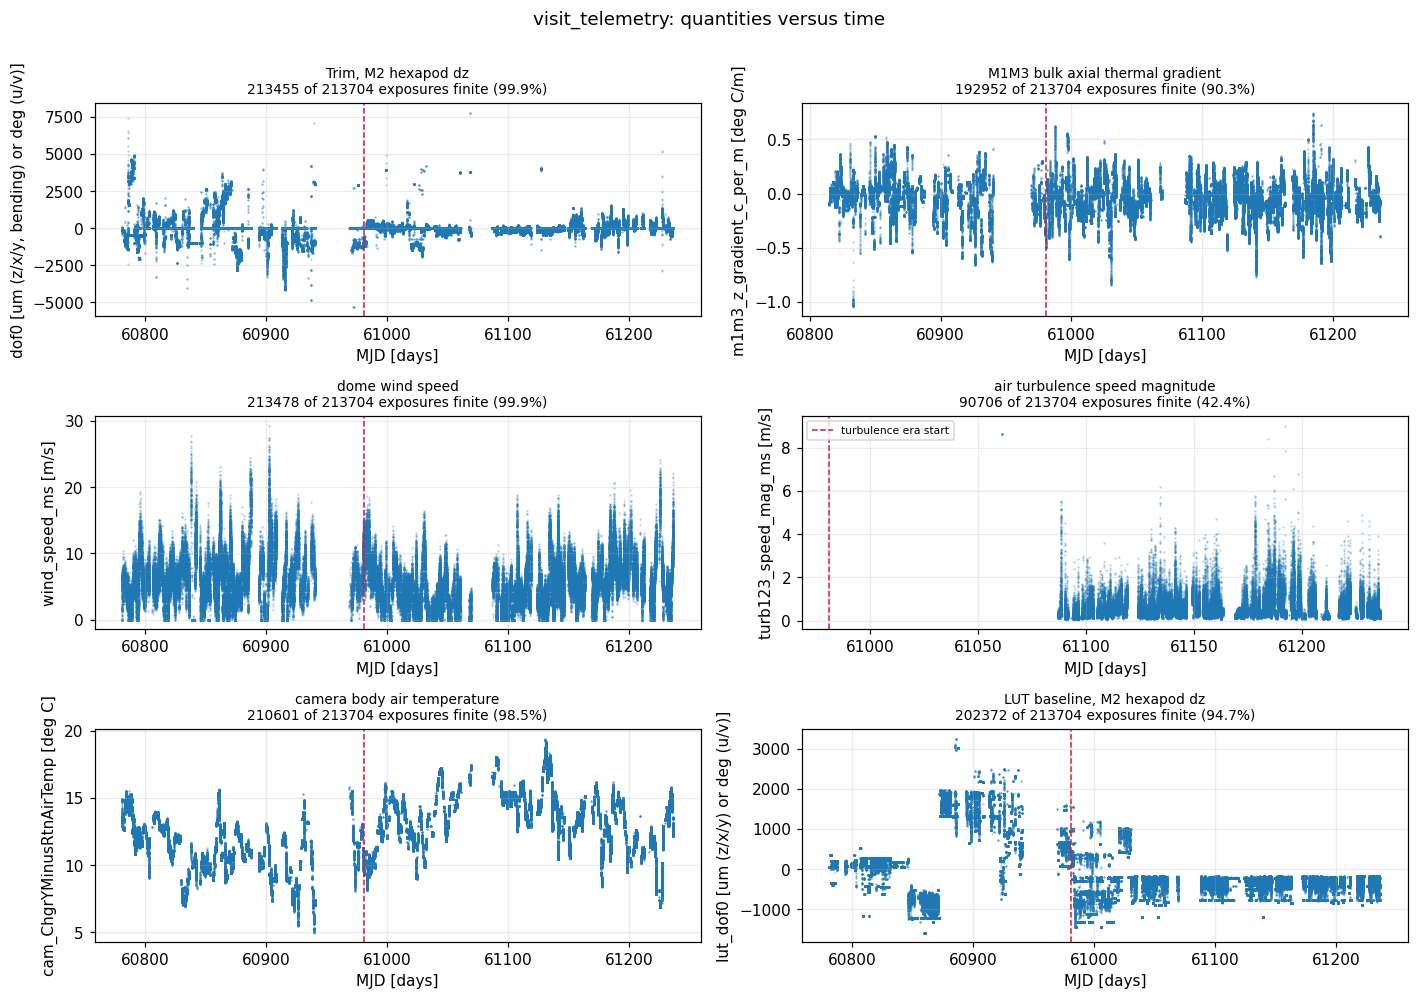

In [9]:
# Time series: the gaps and the era boundary are the point of these panels.
panels = [
    ("dof0", "Trim, M2 hexapod dz"),
    ("m1m3_z_gradient_c_per_m", "M1M3 bulk axial thermal gradient"),
    ("wind_speed_ms", "dome wind speed"),
    ("turb123_speed_mag_ms", "air turbulence speed magnitude"),
    ("cam_ChgrYMinusRtnAirTemp", "camera body air temperature"),
    ("lut_dof0", "LUT baseline, M2 hexapod dz"),
]
fig, axes = plt.subplots(3, 2, figsize=FIGSIZE_GRID)
for ax, (col, title) in zip(axes.ravel(), panels):
    plot_vs_time(ax, vt["mjd"].to_numpy(), vt[col].to_numpy(float),
                 label_for(col), title)
for ax in axes.ravel():
    ax.axvline(Time("2025-11-02T00:00:00", scale="tai").mjd, color="crimson",
               lw=1.0, ls="--", label="turbulence era start")
axes.ravel()[3].legend(fontsize=7, loc="upper left")
fig.suptitle("visit_telemetry: quantities versus time", y=1.005)
fig.tight_layout()

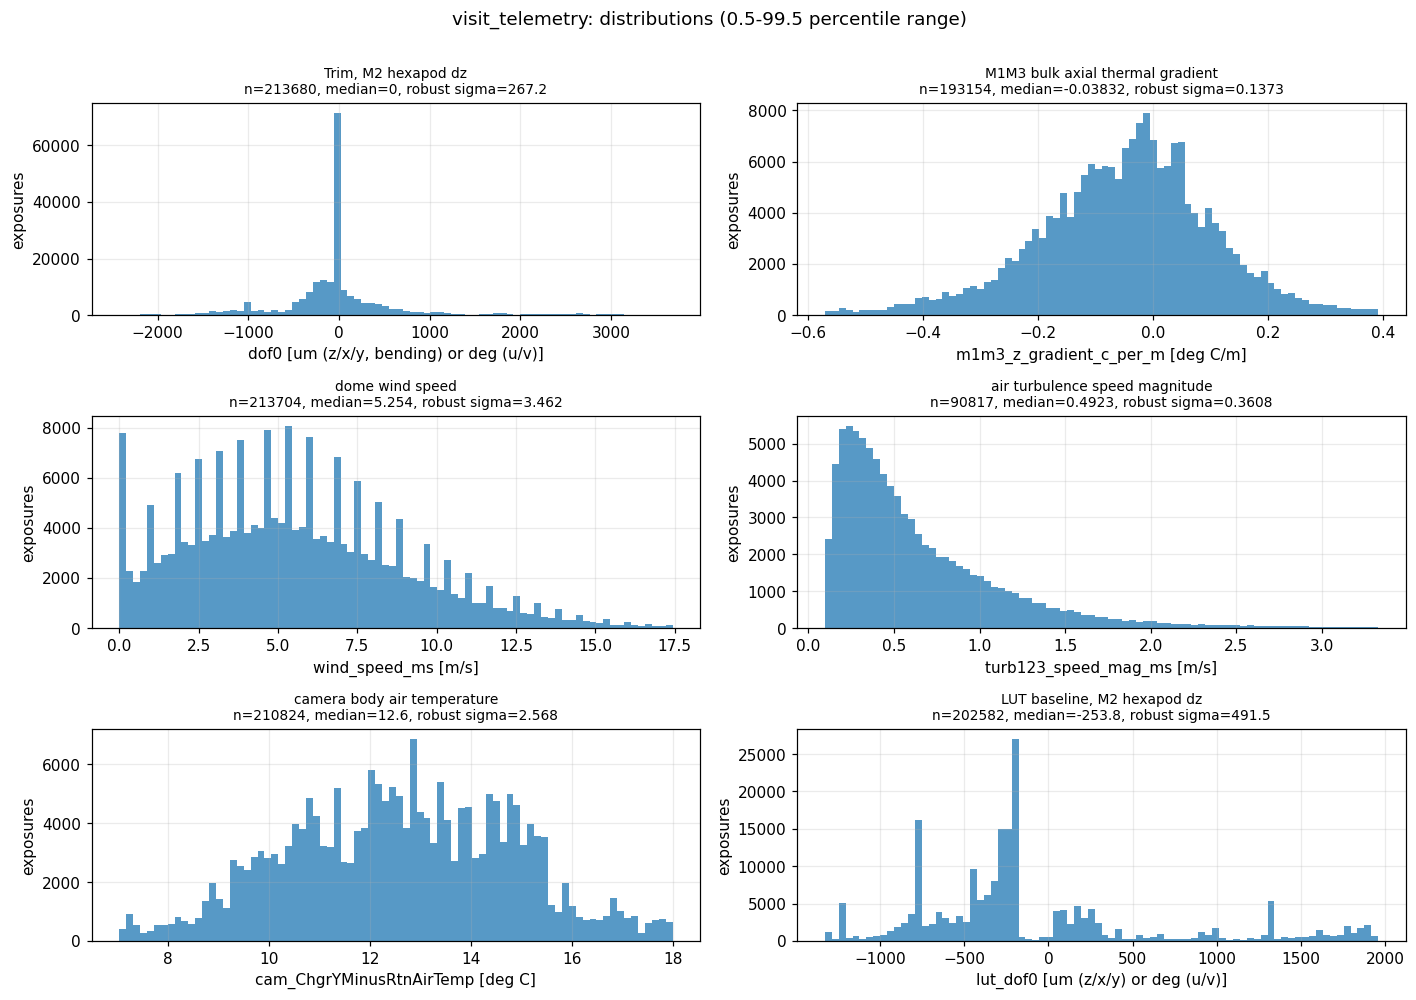

In [10]:
# Histograms of the same quantities.
fig, axes = plt.subplots(3, 2, figsize=FIGSIZE_GRID)
for ax, (col, title) in zip(axes.ravel(), panels):
    plot_hist(ax, vt[col].to_numpy(float), label_for(col), title)
fig.suptitle("visit_telemetry: distributions (0.5-99.5 percentile range)", y=1.005)
fig.tight_layout()

median |residual| = 1.421e-14 deg over 213564 exposures


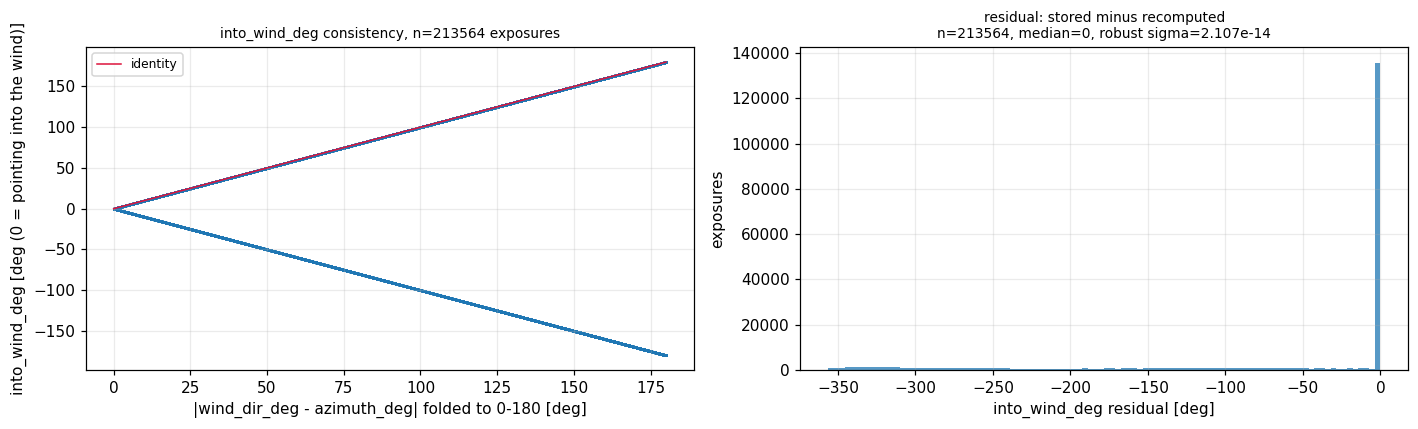

In [11]:
# A physical consistency check rather than a coverage check: the dome-relative wind
# angle should be reconstructible from the wind direction and the telescope azimuth.
d = vt.dropna(subset=["wind_dir_deg", "azimuth_deg", "into_wind_deg"]).copy()
delta = (d["wind_dir_deg"] - d["azimuth_deg"]).to_numpy() % 360.0
delta = np.where(delta > 180.0, 360.0 - delta, delta)
resid = d["into_wind_deg"].to_numpy() - delta

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
axes[0].scatter(delta, d["into_wind_deg"], s=2, alpha=0.2, lw=0)
axes[0].plot([0, 180], [0, 180], color="crimson", lw=1.0, label="identity")
axes[0].set_xlabel("|wind_dir_deg - azimuth_deg| folded to 0-180 [deg]")
axes[0].set_ylabel(label_for("into_wind_deg"))
axes[0].set_title(f"into_wind_deg consistency, n={len(d)} exposures", fontsize=9)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)
plot_hist(axes[1], resid, "into_wind_deg residual [deg]",
          "residual: stored minus recomputed", bins=100)
fig.tight_layout()
print(f"median |residual| = {np.nanmedian(np.abs(resid)):.4g} deg over {len(d)} exposures")

<a id='state'></a>
## 6. `optical_state` and `fam_dz` Validation

`optical_state` holds the optical state recovered from corner-wavefront-sensor data;
`fam_dz` holds Double Zernike (DZ) fits from Full Array Mode (FAM) intra/extra-focal
pairs. Both store their vector quantities as DuckDB `LIST` columns, so they need
unnesting rather than a plain column read.

Two traps live here. `optical_state` registers three variants but populates only one, and
asking for an unpopulated variant returns zero rows rather than raising. And
`optical_state` spans a narrower date range than `visit_telemetry`, so a join drops the
earlier nights.

In [12]:
print("registered state variants versus rows actually present:")
print(q("""
    SELECT sv.variant_id, sv.intrinsic_route, sv.n_dof, sv.n_modes,
           COUNT(os.visit_id) AS rows_present
    FROM state_variant sv
    LEFT JOIN optical_state os USING (variant_id)
    GROUP BY ALL ORDER BY rows_present DESC
""").to_string(index=False))
print("\nA variant with rows_present = 0 returns an empty result, not an error.")

print("\ndate span of each table, via visit_telemetry:")
print(q("""
    SELECT 'visit_telemetry' AS tbl, MIN(day_obs) AS first_day_obs,
           MAX(day_obs) AS last_day_obs, COUNT(*) AS rows FROM visit_telemetry
    UNION ALL
    SELECT 'optical_state', MIN(v.day_obs), MAX(v.day_obs), COUNT(*)
    FROM optical_state o JOIN visit_telemetry v USING (visit_id)
    UNION ALL
    SELECT 'fam_dz', MIN(day_obs), MAX(day_obs), COUNT(*) FROM fam_dz
""").to_string(index=False))

registered state variants versus rows actually present:
               variant_id intrinsic_route  n_dof  n_modes  rows_present
v50_34__batoid__consdb_v1          batoid     50       34         90695
v22_12__batoid__consdb_v1          batoid     22       12             0
   v50_34__miw__consdb_v1             miw     50       34             0

A variant with rows_present = 0 returns an empty result, not an error.

date span of each table, via visit_telemetry:
            tbl  first_day_obs  last_day_obs   rows
visit_telemetry       20250415      20260714 213704
  optical_state       20251102      20260713  90695
         fam_dz       20250415      20260713   2528


In [13]:
# v_modes is a LIST column: unnest with a generated index to pull individual modes.
VARIANT = q("""SELECT variant_id FROM optical_state GROUP BY 1
               ORDER BY COUNT(*) DESC LIMIT 1""")["variant_id"].iloc[0]
print(f"using the populated variant: {VARIANT}")

os_v = q("""
    SELECT o.visit_id, v.day_obs, v.obs_start, o.resid_rms_um, o.ok,
           o.v_modes[1] AS v1, o.v_modes[2] AS v2, o.v_modes[3] AS v3
    FROM optical_state o
    JOIN visit_telemetry v USING (visit_id)
    WHERE o.variant_id = $vid
    ORDER BY o.visit_id
""", vid=VARIANT)
os_v["mjd"] = mjd_from_obs_start(os_v["obs_start"])
print(f"{len(os_v)} rows; ok flag true for {int(os_v['ok'].sum())}")
os_v.head(3)

using the populated variant: v50_34__batoid__consdb_v1
90695 rows; ok flag true for 85819


,visit_id,day_obs,obs_start,resid_rms_um,ok,v1,v2,v3,mjd
0,2025110200004,20251102,2025-11-03T00:04:18.210000,0.639019,True,0.227902,-0.104246,0.089150,60982.002989
1,2025110200005,20251102,2025-11-03T00:04:54.538000,0.562522,True,0.157386,-0.192999,0.080562,60982.003409
2,2025110200006,20251102,2025-11-03T00:06:34.087000,1.277546,True,0.101812,-0.482204,0.127451,60982.004561


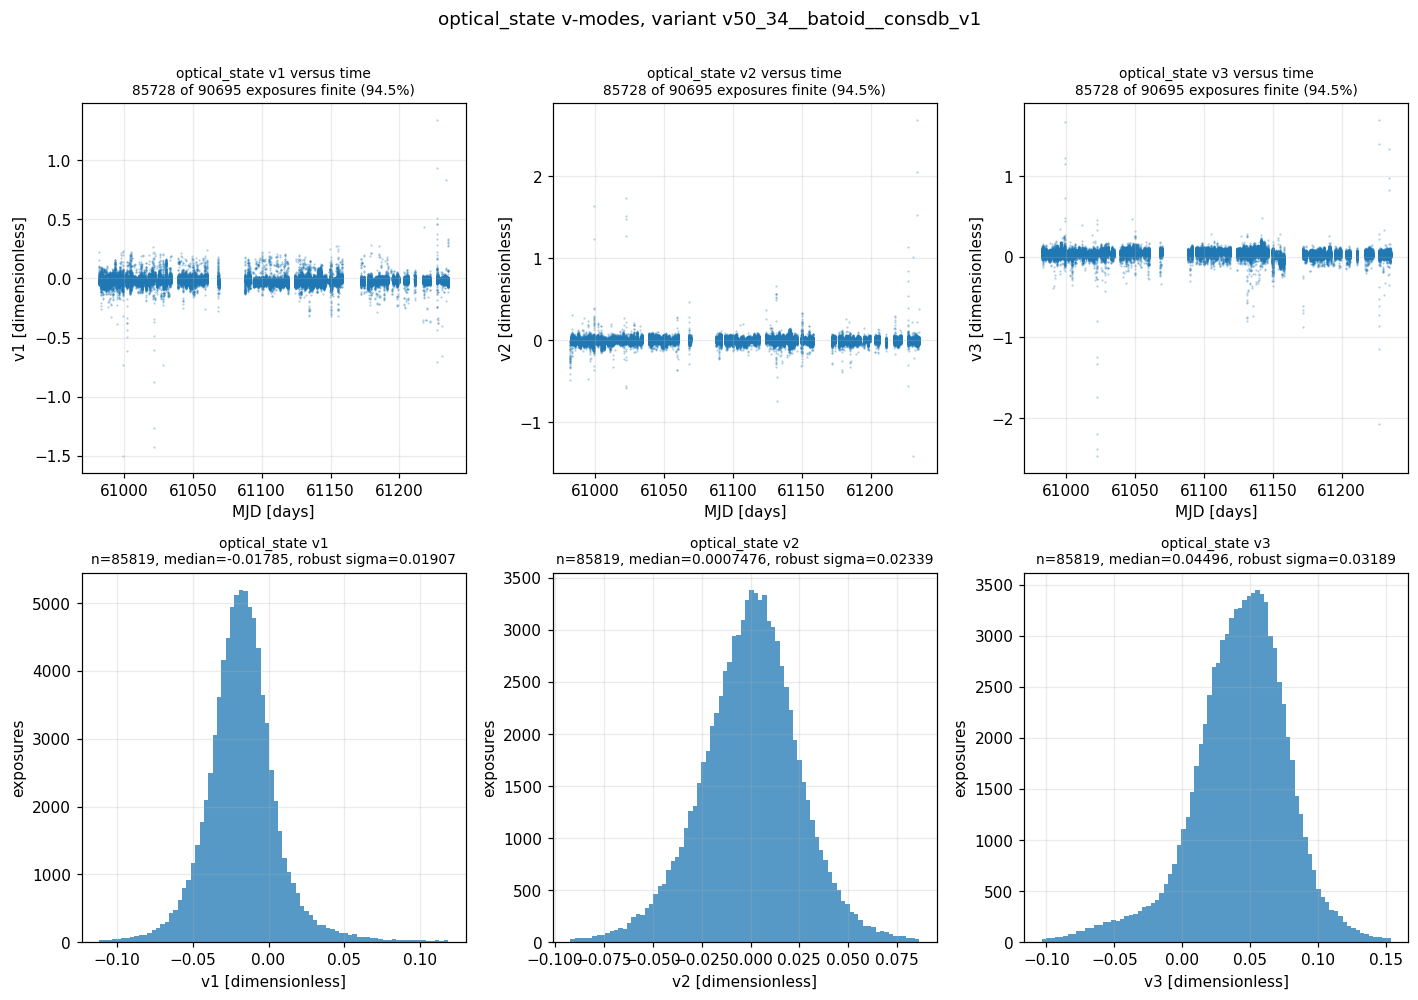

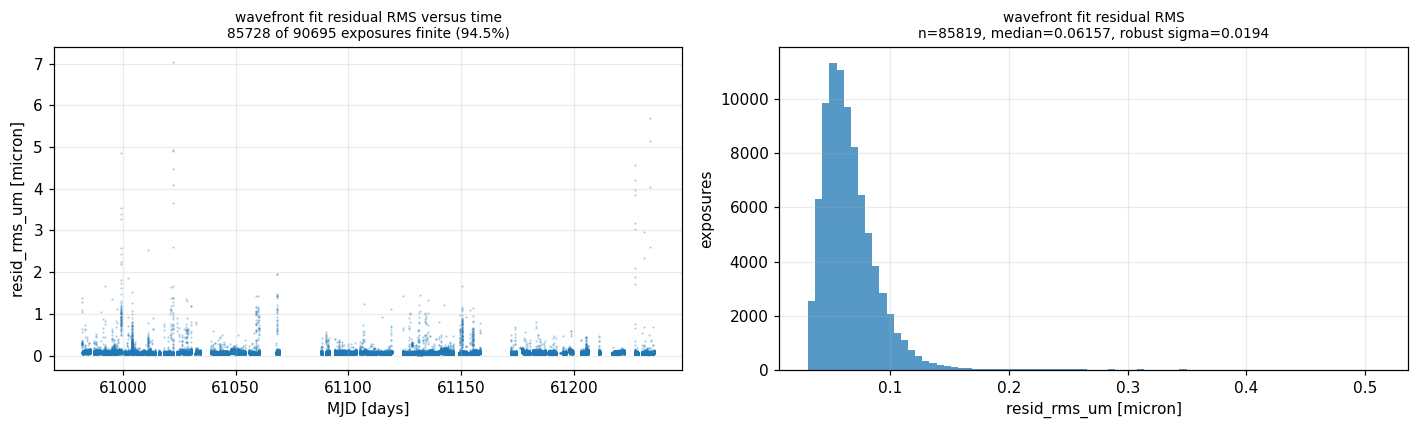

In [14]:
fig, axes = plt.subplots(2, 3, figsize=FIGSIZE_GRID)
for j, m in enumerate(["v1", "v2", "v3"]):
    plot_vs_time(axes[0, j], os_v["mjd"].to_numpy(), os_v[m].to_numpy(float),
                 f"{m} [dimensionless]", f"optical_state {m} versus time")
    plot_hist(axes[1, j], os_v[m].to_numpy(float), f"{m} [dimensionless]",
              f"optical_state {m}")
fig.suptitle(f"optical_state v-modes, variant {VARIANT}", y=1.005)
fig.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
plot_vs_time(axes[0], os_v["mjd"].to_numpy(), os_v["resid_rms_um"].to_numpy(float),
             "resid_rms_um [micron]", "wavefront fit residual RMS versus time")
plot_hist(axes[1], os_v["resid_rms_um"].to_numpy(float),
          "resid_rms_um [micron]", "wavefront fit residual RMS")
fig.tight_layout()

2528 FAM fits; bad_fit=63, quality_pass=2528
joined to visit_telemetry: 2528 of 2528


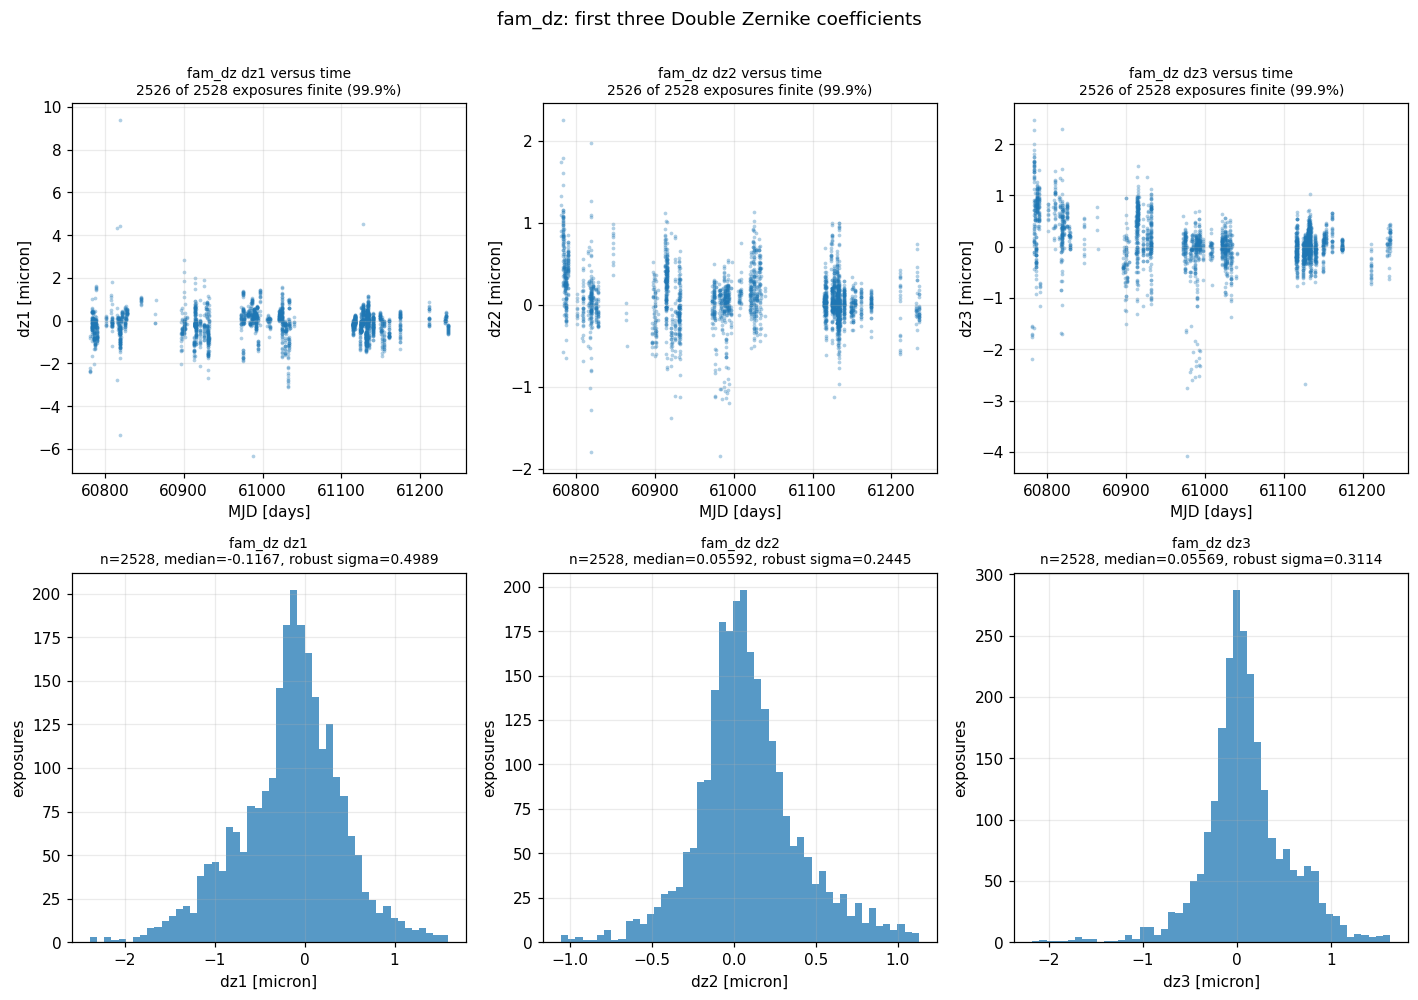

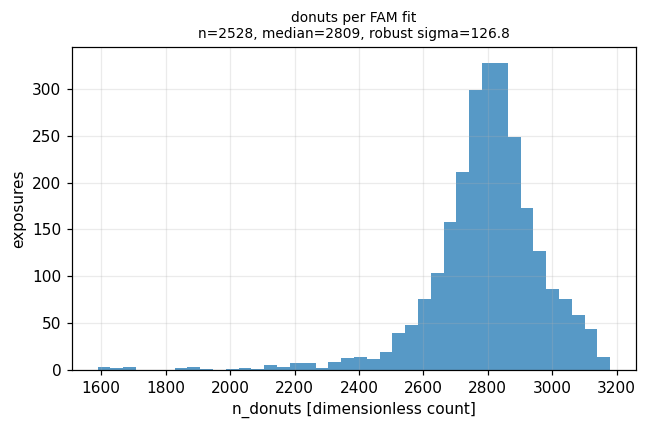

In [15]:
# fam_dz: DZ coefficients per FAM pair. dz_coeff is also a LIST column.
fam = q("""
    SELECT f.visit_id, f.day_obs, f.n_donuts, f.n_modes, f.bad_fit, f.quality_pass,
           f.dz_coeff[1] AS dz1, f.dz_coeff[2] AS dz2, f.dz_coeff[3] AS dz3,
           v.obs_start
    FROM fam_dz f LEFT JOIN visit_telemetry v USING (visit_id)
    ORDER BY f.visit_id
""")
fam["mjd"] = mjd_from_obs_start(fam["obs_start"])
print(f"{len(fam)} FAM fits; bad_fit={int(fam['bad_fit'].sum())}, "
      f"quality_pass={int(fam['quality_pass'].sum())}")
print(f"joined to visit_telemetry: {int(fam['obs_start'].notna().sum())} of {len(fam)}")

fig, axes = plt.subplots(2, 3, figsize=FIGSIZE_GRID)
for j, m in enumerate(["dz1", "dz2", "dz3"]):
    plot_vs_time(axes[0, j], fam["mjd"].to_numpy(), fam[m].to_numpy(float),
                 f"{m} [micron]", f"fam_dz {m} versus time", s=6)
    plot_hist(axes[1, j], fam[m].to_numpy(float), f"{m} [micron]", f"fam_dz {m}", bins=50)
fig.suptitle("fam_dz: first three Double Zernike coefficients", y=1.005)
fig.tight_layout()

fig, ax = plt.subplots(figsize=(6, 4))
plot_hist(ax, fam["n_donuts"].to_numpy(float), "n_donuts [dimensionless count]",
          "donuts per FAM fit", bins=40, robust=False)
fig.tight_layout()

<a id='smatrix'></a>
## 7. Sensitivity-Matrix Blocks: Which DOF Moved

The sensitivity-matrix campaign perturbs one degree of freedom at a time and measures the
wavefront response. Two campaigns are covered here: `BLOCK-T377` through `BLOCK-T380` in
April to June 2025, and `BLOCK-T598` "Sensitivity Matrix Repeatability" in August 2025,
which re-measures a subset of the same DOF to test reproducibility.

Two block numbers inside the first campaign's night range are excluded by name, because
neither carries a perturbation: `BLOCK-T381` is the unperturbed `reference_wavefront`
measurement, and `BLOCK-T382` is 650 detector bias frames labelled
`observation_reason = "block-335"` — calibration data tagged with a campaign block number.

The block identity is **not** in this database — it lives in the Consolidated Database
(ConsDB) `science_program` column, so this section needs `ConsDbClient`. Everything else
comes from the `dof*` Trim columns here.

**The observing pattern is what makes this identifiable**, and it has two nested levels:

- A **Full Array Mode (FAM) triplet** is three consecutive exposures with `img_type`
  `cwfs`, `cwfs`, `acq`, in which camera hexapod dz (`dof5`) is offset by **−1500 micron,
  then +1500 micron, then returned to the in-focus value**. The two defocused `cwfs`
  exposures are the intra/extra-focal pair the wavefront is fitted from, so a triplet is
  recognised by a `dof5` span of exactly 3000 micron across that pair, with the `acq`
  exposure at the midpoint.
- A **ladder** is a run of five such triplets in which **one other DOF** is stepped through
  `-Delta, -Delta/2, 0, +Delta/2, +Delta`. That DOF is the quantity under test, and the
  uniform step size is the amplitude of the perturbation.

ConsDB's `group_id` gives both levels, though asymmetrically: the bare timestamp is the
ladder key, and `<timestamp>#<n>` is the key of the n-th triplet — carried by the `cwfs`
pair only. The `acq` exposure repeats the bare timestamp, so it is attached to its triplet
by observing order instead.

**Use Trim, not Tweak.** Trim is the absolute commanded correction, so a ladder is five
Trim values in arithmetic progression — the shape is visible directly, the step size is
read off, and no differencing is needed. Within a single ladder, lasting minutes, nothing
else moves, so the perturbed DOF is simply the one with the largest Trim range once
`dof5` is set aside.

**What the cross-check in Step 3 compares.** The *observed* DOF is the one recovered from
the commanded **Trim** columns (`dof0`–`dof49`, the EFD `MTAOS_degreeOfFreedom` topic) as
just described; the *expected* DOF is the index implied by the ConsDB
`observation_reason` text, either through the `ts_ofc` rigid-body ordering or through the
bending-mode index convention. Nothing else enters: no look-up table, no fit, and no
wavefront measurement. The check therefore tests whether the telescope was commanded to
move the DOF the observing script said it was moving — nothing about whether the resulting
wavefront response was correct.

In [16]:
import os
from pathlib import Path

from lsst.summit.utils import ConsDbClient


def make_consdb_client():
    """Build a `ConsDbClient` with the endpoint resolved for this environment.

    Returns
    -------
    client : `lsst.summit.utils.ConsDbClient`
        A client pointed at an endpoint that resolves from where this is running.

    Notes
    -----
    The two ConsDB endpoints are not interchangeable. The internal host
    ``consdb-pq.consdb`` resolves **only** inside the Rubin Science Platform (RSP)
    JupyterLab pod, and must bypass the RSP HTTP proxy or it returns 502 Bad Gateway.
    Elsewhere -- an S3DF login node, a batch node, a laptop -- that host does not
    resolve at all, so the public endpoint is used with an RSP access token injected
    into the URL. The token file is read at call time and preferred over
    ``$ACCESS_TOKEN``, which may have expired.

    Constructing ``ConsDbClient()`` with no argument instead requires
    ``$LSST_CONSDB_PQ_URL`` to be set, which is true in the RSP but not on S3DF.
    """
    in_rsp = os.path.isdir("/etc/nublado")
    no_proxy = os.environ.get("no_proxy", "")
    if ".consdb" not in no_proxy:
        os.environ["no_proxy"] = f"{no_proxy},.consdb" if no_proxy else ".consdb"
    if in_rsp:
        return ConsDbClient("http://consdb-pq.consdb:8080/consdb")
    url = "https://usdf-rsp.slac.stanford.edu/consdb"
    tf = Path.home() / ".lsst" / "consdb_token"
    token = tf.read_text().strip() if tf.exists() else os.environ.get("ACCESS_TOKEN")
    if token:
        url = url.replace("://", f"://user:{token}@", 1)
    return ConsDbClient(url)


def fetch_exposures(client, day_obs_ranges):
    """Fetch the ConsDB exposure records needed to identify the observing pattern.

    Parameters
    ----------
    client : `lsst.summit.utils.ConsDbClient`
        An open ConsDB client.
    day_obs_ranges : `list` [`tuple`]
        Inclusive ``(first_day_obs, last_day_obs)`` pairs, one per campaign.

    Returns
    -------
    exp : `pandas.DataFrame`
        One row per exposure over the union of the ranges, with the block identity,
        the observing intent, the image type and the group key.

    Notes
    -----
    One query per range rather than a single ``BETWEEN`` spanning all of them: the two
    campaigns are months apart, so one wide range would pull a whole season of unrelated
    exposures across the network.

    The block name is filtered client-side with pandas rather than in SQL. The ConsDB
    server returns HTTP 500 on ``WHERE science_program LIKE 'BLOCK-T37%'`` -- a LIKE with
    a trailing wildcard -- and on an OR chain of them.
    """
    parts = []
    for d0, d1 in day_obs_ranges:
        # ConsDbClient.query returns an astropy Table, not a DataFrame.
        parts.append(client.query(f"""
            SELECT exposure_id AS visit_id, day_obs, seq_num,
                   science_program, observation_reason, img_type, group_id
            FROM {CONSDB_SCHEMA}.exposure
            WHERE day_obs BETWEEN {d0} AND {d1}
        """).to_pandas())
    return pd.concat(parts, ignore_index=True)


consdb = make_consdb_client()
exp = fetch_exposures(consdb, SMATRIX_DAY_OBS_RANGES)

exp["science_program"] = exp["science_program"].astype(str)
sm = exp[exp["science_program"].str.match(SMATRIX_BLOCK_RE)].copy()

ranges_txt = ", ".join(f"{a} to {b}" for a, b in SMATRIX_DAY_OBS_RANGES)
print(f"{len(sm)} sensitivity-matrix exposures in ConsDB over day_obs {ranges_txt}")
print(f"\nexposures per block [dimensionless count]:")
print(sm.groupby("science_program").size().to_string())
print("\nimg_type, the FAM triplet structure:")
print(sm["img_type"].value_counts().to_string())
print("\nnights per campaign [dimensionless count of day_obs]:")
for a, b in SMATRIX_DAY_OBS_RANGES:
    s = sm[(sm["day_obs"] >= a) & (sm["day_obs"] <= b)]
    print(f"  day_obs {a} to {b}: {len(s)} exposures on "
          f"{s['day_obs'].nunique()} nights, blocks "
          f"{sorted(set(s['science_program'].str.split('_').str[0]))}")

        Use pytest instead. [astropy.tests.runner]


        Use pytest instead. [astropy.utils.decorators]


1314 sensitivity-matrix exposures in ConsDB over day_obs 20250415 to 20250610, 20250801 to 20250831

exposures per block [dimensionless count]:
science_program
BLOCK-T377       75
BLOCK-T378       21
BLOCK-T378_0     77
BLOCK-T378_1    139
BLOCK-T378_2     80
BLOCK-T378_3     95
BLOCK-T379       18
BLOCK-T379_0     93
BLOCK-T379_1     75
BLOCK-T379_2     75
BLOCK-T379_3     75
BLOCK-T380      249
BLOCK-T598      242

img_type, the FAM triplet structure:
img_type
cwfs    852
acq     462

nights per campaign [dimensionless count of day_obs]:
  day_obs 20250415 to 20250610: 1072 exposures on 12 nights, blocks ['BLOCK-T377', 'BLOCK-T378', 'BLOCK-T379', 'BLOCK-T380']
  day_obs 20250801 to 20250831: 242 exposures on 5 nights, blocks ['BLOCK-T598']


In [17]:
# Pull Trim for the same nights and join on visit_id.
TR = [f"dof{i}" for i in range(50)]
_where = " OR ".join(f"day_obs BETWEEN {a} AND {b}" for a, b in SMATRIX_DAY_OBS_RANGES)
tr = q(f"""
    SELECT visit_id, {', '.join(TR)}
    FROM visit_telemetry WHERE {_where}
""")
m = sm.merge(tr, on="visit_id", how="inner")
print(f"joined to visit_telemetry: {len(m)} of {len(sm)} exposures "
      f"({100.0 * len(m) / max(len(sm), 1):.1f}%)")

# observation_reason carries an intra/extra/infocus prefix per exposure of a triplet;
# strip it so the three exposures of one measurement group together.
m["reason"] = (m["observation_reason"].astype(str)
               .str.replace(r"^(intra|extra|infocus)_", "", regex=True))
m["group_id"] = m["group_id"].astype(str)

# Keep only on-sky exposures. With the block list restricted to the four blocks that
# actually carry ladders plus BLOCK-T598, this should now drop nothing: the 650 bias
# frames that a looser block selection pulled in all belonged to BLOCK-T382, which is
# excluded by name. The check stays because a silent influx of calibration frames would
# otherwise dilute every DOF range.
obs = m[m["img_type"] != "bias"].sort_values(["day_obs", "seq_num"]).copy()
n_drop = len(m) - len(obs)
print(f"\n{len(obs)} on-sky exposures"
      + (f" ({n_drop} non-sky frames set aside)" if n_drop else
         " -- no bias or other non-sky frames present, as expected"))

# group_id keys both levels, but asymmetrically. The ladder key is the bare timestamp,
# shared by every exposure of the ladder. The triplet key is "<timestamp>#<n>" for the
# n-th triplet -- and only the two defocused cwfs exposures carry the "#n" suffix. The
# in-focus acq exposure repeats the bare timestamp, so its triplet has to be recovered
# from the observing order: it is taken by the exposure sequence and so belongs to the
# cwfs pair it directly follows.
obs["ladder"] = obs["group_id"].str.split("#").str[0]
_suffixed = obs["group_id"].str.contains(r"#\d+$", regex=True)
obs["triplet"] = obs["group_id"].where(_suffixed)
obs["triplet"] = obs.groupby("ladder")["triplet"].ffill()
n_acq = int((obs["img_type"] == "acq").sum())
n_keyed = int(((obs["img_type"] == "acq") & obs["triplet"].notna()).sum())
print(f"acq exposures assigned to a triplet by sequence order: {n_keyed} of {n_acq}")

print("\nwhat each block was perturbing, from ConsDB observation_reason:")
for prog, g in sorted(obs.groupby("science_program")):
    kinds = sorted(set(g["reason"]))
    print(f"  {prog:22s} n={len(g):4d}  {kinds[:6]}{' ...' if len(kinds) > 6 else ''}")

joined to visit_telemetry: 1314 of 1314 exposures (100.0%)

1314 on-sky exposures -- no bias or other non-sky frames present, as expected
acq exposures assigned to a triplet by sequence order: 426 of 462

what each block was perturbing, from ConsDB observation_reason:
  BLOCK-T377             n=  75  ['sensitivity_cam_drx', 'sensitivity_cam_dry', 'sensitivity_cam_dx', 'sensitivity_cam_dy', 'sensitivity_cam_dz']
  BLOCK-T378             n=  21  ['acq', 'z11_sensitivity']
  BLOCK-T378_0           n=  77  ['sensitivity_m1m3_b1', 'sensitivity_m1m3_b2', 'sensitivity_m1m3_b3', 'sensitivity_m1m3_b4', 'sensitivity_m1m3_b5']
  BLOCK-T378_1           n= 139  ['sensitivity_m1m3_b10', 'sensitivity_m1m3_b6', 'sensitivity_m1m3_b7', 'sensitivity_m1m3_b8', 'sensitivity_m1m3_b9']
  BLOCK-T378_2           n=  80  ['sensitivity_m1m3_b11', 'sensitivity_m1m3_b12', 'sensitivity_m1m3_b13', 'sensitivity_m1m3_b14', 'sensitivity_m1m3_b15']
  BLOCK-T378_3           n=  95  ['sensitivity_m1m3_b16', 'sensitivity_m

### Step 1: find the FAM triplets

A triplet is identified by its camera hexapod dz (`dof5`) signature, not by counting
exposures: the two `cwfs` exposures differ by 3000 micron in `dof5`, and the `acq`
exposure sits exactly midway between them, at the in-focus value.

That midpoint is the real test of the pattern. If the intra/extra pair is a symmetric
±1500 micron offset *about* the in-focus position, then the in-focus `dof5` must equal the
mean of the pair — so comparing the two is a check on the observing script rather than a
restatement of how the triplet was found.

The absolute `dof5` value is **not** ±1500 micron. It is the local in-focus baseline ±1500
micron, and that baseline is itself a few thousand micron from zero and drifts night to
night as the look-up table and closed loop track elevation and temperature. The ±1500
micron is a deliberate offset about the baseline, so the span between the pair — exactly
3000 micron — is the invariant to key on.

The 50-element DOF ordering comes from `ts_ofc` (`OFCData.comp_dof_idx`): `dof0`-`dof4`
M2 hexapod, `dof5`-`dof9` camera hexapod, `dof10`-`dof29` M1M3 bending modes,
`dof30`-`dof49` M2 bending modes. Within each hexapod the order is dz, dx, dy, rx, ry,
so `dof5` being camera hexapod dz is what makes it the defocus DOF.

In [18]:
DOF_GROUPS = [(0, 5, "M2 hexapod"), (5, 10, "camera hexapod"),
              (10, 30, "M1M3 bending"), (30, 50, "M2 bending")]
DEFOCUS_DOF = 5            # camera hexapod dz: the FAM intra/extra offset
FAM_DZ_SPAN_UM = 3000.0    # dof5 span between the intra and extra cwfs exposures
FAM_SPAN_TOL_UM = 100.0    # tolerance on that span

# The ts_ofc rigid-body DOF index each observation_reason should be stepping. Two naming
# conventions appear for the hexapod rotations: BLOCK-T377 and BLOCK-T380 write "drx" and
# "dry", while BLOCK-T598 writes "rx" and "ry" for the same two DOF. Both spellings are
# mapped so a reason from either campaign resolves.
RIGID_EXPECTED = {"m2_dz": 0, "m2_dx": 1, "m2_dy": 2, "m2_drx": 3, "m2_dry": 4,
                  "cam_dz": 5, "cam_dx": 6, "cam_dy": 7, "cam_drx": 8, "cam_dry": 9,
                  "m2_rx": 3, "m2_ry": 4, "cam_rx": 8, "cam_ry": 9}

# The reason spellings that name a rigid-body DOF, as one alternation for re.match.
RIGID_SUFFIX_RE = r"sensitivity_(m2|cam)_(dz|dx|dy|drx|dry|rx|ry)$"


def dof_group_name(i):
    """Name of the subsystem that DOF index `i` belongs to."""
    for lo, hi, name in DOF_GROUPS:
        if lo <= i < hi:
            return name
    return "?"


def find_triplets(frame):
    """Locate the FAM intra/extra/in-focus triplets in a set of exposures.

    A triplet is a `triplet` key whose two `cwfs` exposures differ in camera hexapod dz
    (`dof5`) by `FAM_DZ_SPAN_UM`, within `FAM_SPAN_TOL_UM`.

    Parameters
    ----------
    frame : `pandas.DataFrame`
        On-sky exposures carrying `triplet`, `img_type` and the `dof0`-`dof49` columns.

    Returns
    -------
    info : `pandas.DataFrame`
        One row per triplet, indexed by `triplet`, with columns ``dz_span`` (micron),
        ``dz_focus`` (the in-focus `dof5`, micron), ``dz_mid`` (the midpoint of the
        `cwfs` pair, micron), ``n_cwfs`` and ``n_acq`` (dimensionless counts).
    """
    cw = frame[frame["img_type"] == "cwfs"].groupby("triplet")["dof5"]
    acq = frame[frame["img_type"] == "acq"].groupby("triplet")["dof5"]
    info = pd.DataFrame({"dz_span": cw.max() - cw.min(), "dz_mid": cw.mean(),
                         "n_cwfs": cw.size(), "dz_focus": acq.mean(),
                         "n_acq": acq.size()})
    info = info.fillna({"n_acq": 0})
    keep = (info["n_cwfs"] == 2) & (
        (info["dz_span"] - FAM_DZ_SPAN_UM).abs() < FAM_SPAN_TOL_UM)
    return info[keep]


tri = find_triplets(obs)
print(f"{len(tri)} FAM triplets found, out of "
      f"{obs['triplet'].nunique()} exposure groups")
print(f"dof5 span between the intra and extra cwfs exposures: "
      f"median {tri['dz_span'].median():.1f} micron, "
      f"range {tri['dz_span'].min():.1f} to {tri['dz_span'].max():.1f} micron")
print(f"in-focus dof5 baseline across triplets: "
      f"{tri['dz_focus'].min():.1f} to {tri['dz_focus'].max():.1f} micron "
      f"-- far from zero and drifting, which is why the span is the invariant")

# The in-focus exposure is the real test of the pattern: if the cwfs pair is a
# symmetric +-1500 micron offset about the in-focus position, the acq exposure's dof5
# must equal the midpoint of the pair exactly.
with_acq = tri[tri["n_acq"] > 0]
off = (with_acq["dz_focus"] - with_acq["dz_mid"]).abs()
print(f"triplets with the in-focus acq exposure present: {len(with_acq)} of {len(tri)}")
print(f"|acq dof5 - midpoint of the cwfs pair|: median {np.nanmedian(off):.4g} micron, "
      f"max {np.nanmax(off):.4g} micron over {len(with_acq)} triplets")
print("The offset is a symmetric -1500, +1500, 0 micron about the in-focus baseline.")

425 FAM triplets found, out of 430 exposure groups
dof5 span between the intra and extra cwfs exposures: median 3000.0 micron, range 3000.0 to 3000.0 micron
in-focus dof5 baseline across triplets: -6111.4 to 931.2 micron -- far from zero and drifting, which is why the span is the invariant
triplets with the in-focus acq exposure present: 420 of 425
|acq dof5 - midpoint of the cwfs pair|: median 0 micron, max 0 micron over 420 triplets
The offset is a symmetric -1500, +1500, 0 micron about the in-focus baseline.


### Step 2: find the ladders and the DOF each one stepped

Within one ladder — five triplets over a few minutes — the only thing that moves is the
commanded perturbation, so the perturbed DOF is the one with the largest Trim range once
`dof5` is excluded. No recurrence counting or outlier rejection is needed; the window is
short enough that there is nothing to reject.

Two properties make this self-validating. The five Trim values should be in **arithmetic
progression**, which `uniform_step` checks, so a ladder that fails is flagged rather than
silently mislabelled. And the step size falls out directly in the DOF's own units, giving
the perturbation amplitude that a sensitivity-matrix column has to be divided by.

Each ladder also carries its inclusive **`seq_num` range** on its night, in `seq_range`.
That is the handle for going back to the images: `day_obs` plus a `seq_num` range is what
a Butler or ConsDB query needs, and because a ladder is observed as one uninterrupted
sequence the range is contiguous — 15 exposures for a five-triplet ladder.

Identification is **per ladder, not per `observation_reason`**: the same reason can appear
on several nights with different amplitudes, and — as the next cell shows — occasionally
on a different DOF. `BLOCK-T598` makes this explicit, since repeating a measurement is
the point of that block, so several of its reasons appear as two or three separate
ladders, distinguished by `day_obs` and `seq_range`.

In [19]:
def identify_ladders(frame, triplets, min_triplets=3):
    """Find the perturbation ladders and the DOF each one stepped.

    A ladder is the set of FAM triplets sharing a `ladder` key. The perturbed DOF is the
    one with the largest Trim range across the ladder's triplets, excluding the defocus
    DOF. A ladder lasts minutes, so nothing but the commanded perturbation moves.

    Parameters
    ----------
    frame : `pandas.DataFrame`
        On-sky exposures carrying `ladder`, `triplet`, `reason`, `day_obs`, `seq_num`
        and `dof0`-`dof49`.
    triplets : `pandas.DataFrame`
        Output of `find_triplets`, used to keep only genuine FAM triplets.
    min_triplets : `int`, optional
        Ignore a ladder with fewer triplets than this.

    Returns
    -------
    ladders : `pandas.DataFrame`
        One row per ladder: the DOF index stepped, the step size in that DOF's own units
        (micron for `dof0`-`dof9`, dimensionless bending amplitude for `dof10`-`dof49`),
        the inclusive `seq_num` range the ladder occupies on its night, whether the steps
        are uniform, and the Trim values in triplet order.
    """
    fam = frame[frame["triplet"].isin(triplets.index)]
    out = []
    for (lad, reason), g in fam.groupby(["ladder", "reason"]):
        # One Trim value per triplet: Trim is constant within a triplet by construction.
        per_tri = g.groupby("triplet")[TR].first()
        if len(per_tri) < min_triplets:
            continue
        rng = (per_tri.max() - per_tri.min()).to_numpy(float)
        rng[DEFOCUS_DOF] = 0.0
        if not np.isfinite(rng).any() or np.nanmax(rng) <= 0:
            continue
        top = int(np.nanargmax(rng))
        vals = np.sort(per_tri[f"dof{top}"].to_numpy(float))
        steps = np.diff(vals)
        # The seq_num range locates the ladder in the night's exposure sequence, which is
        # what a Butler or ConsDB query for its images needs. Ladders are contiguous in
        # seq_num, so the first and last bound every exposure in between.
        seq_lo, seq_hi = int(g["seq_num"].min()), int(g["seq_num"].max())
        out.append({
            "reason": reason, "ladder": lad, "block": sorted(set(g["science_program"]))[0],
            "day_obs": int(g["day_obs"].min()),
            "seq_lo": seq_lo, "seq_hi": seq_hi,
            "seq_range": f"{seq_lo}-{seq_hi}",
            "n_exposures": len(g), "n_triplets": len(per_tri),
            "dof_moved": f"dof{top}", "dof_group": dof_group_name(top),
            "step": round(float(np.median(steps)), 5),
            "span": round(float(rng[top]), 5),
            "uniform_step": bool(np.allclose(steps, steps[0], rtol=1e-3, atol=1e-6)),
            "values": np.round(vals, 4),
        })
    return pd.DataFrame(out).sort_values(["reason", "day_obs", "seq_lo"])


ladders = identify_ladders(obs, tri)
n_u = int(ladders["uniform_step"].sum())
print(f"{len(ladders)} perturbation ladders, {int(ladders['n_triplets'].sum())} triplets")
print(f"ladders whose Trim steps are uniform: {n_u} of {len(ladders)} "
      f"-- the -Delta, -Delta/2, 0, +Delta/2, +Delta pattern")
print("\ntriplets per ladder [dimensionless count]:")
print(ladders["n_triplets"].value_counts().sort_index().to_string())

# Contiguity of the seq_num range: a five-triplet ladder is 15 consecutive exposures, so
# the span should be one less than the exposure count wherever no other observation
# interleaved.
gap = (ladders["seq_hi"] - ladders["seq_lo"] + 1) - ladders["n_exposures"]
print(f"\nladders occupying a contiguous seq_num block: "
      f"{int((gap == 0).sum())} of {len(ladders)}")
if (gap != 0).any():
    print(f"  the rest have {sorted(set(gap[gap != 0]))} extra seq_num "
          f"[dimensionless count] interleaved from other observations")

print("\nstep and span are in micron for dof0-dof9 and a dimensionless bending "
      "amplitude for dof10-dof49; seq_range is inclusive.\n")
print(ladders.drop(columns=["values", "ladder", "seq_lo", "seq_hi"])
      .to_string(index=False))

80 perturbation ladders, 408 triplets
ladders whose Trim steps are uniform: 80 of 80 -- the -Delta, -Delta/2, 0, +Delta/2, +Delta pattern

triplets per ladder [dimensionless count]:
n_triplets
3     2
4     4
5    70
9     4

ladders occupying a contiguous seq_num block: 80 of 80

step and span are in micron for dof0-dof9 and a dimensionless bending amplitude for dof10-dof49; seq_range is inclusive.

              reason        block  day_obs seq_range  n_exposures  n_triplets dof_moved      dof_group       step      span  uniform_step
 sensitivity_cam_drx   BLOCK-T377 20250421   340-354           15           5      dof8 camera hexapod    0.02500    0.1000          True
 sensitivity_cam_dry   BLOCK-T377 20250421   355-369           15           5      dof9 camera hexapod    0.02500    0.1000          True
  sensitivity_cam_dx   BLOCK-T377 20250421   310-324           15           5      dof6 camera hexapod 1250.00000 5000.0000          True
  sensitivity_cam_dy   BLOCK-T377 20250421  

### Step 3: cross-check the recovered DOF against what was requested

`observation_reason` names the intent — `sensitivity_m1m3_b7` for a bending mode,
`sensitivity_m2_dx` for a rigid-body translation — so the DOF recovered from telemetry can
be checked against it.

To be explicit about what the two sides of this comparison are: the **observed** DOF is the
one carrying the largest commanded **Trim** range across the ladder, read from the
`dof0`–`dof49` columns of this database (EFD topic `MTAOS_degreeOfFreedom`) with `dof5`
masked out; the **expected** DOF is the index implied by the ConsDB `observation_reason`
string. Neither side involves the look-up table, a fit, or a wavefront measurement.

The two come from independent places — the commanded Trim in the Engineering Facility
Database and the observing script's own label in ConsDB — so agreement is a real test
rather than a restatement.

The expected index is obtained two different ways:

- For the **bending modes** the check is an index convention: the recovered DOF index minus
  the block base (10 for M1M3, 30 for M2) minus the requested mode number should be a
  single constant for every mode of both mirrors.
- For the **rigid-body** reasons the expected index is fixed outright by the `ts_ofc`
  ordering, so any disagreement is a mislabelling. Note that the two campaigns spell the
  hexapod rotations differently — `drx`/`dry` in `BLOCK-T377` and `BLOCK-T380`, `rx`/`ry`
  in `BLOCK-T598` — and both spellings map to the same DOF.

This is exactly the check worth running before trusting a sensitivity matrix, and here it
finds two things: one night stepped the wrong hexapod, and one ladder landed on the wrong
mirror's bending block.

In [20]:
# --- bending modes: the index convention should be one constant offset ---
bend = []
for r in ladders.itertuples():
    mm = re.match(r"sensitivity_(m1m3|m2)_b(\d+)$", r.reason)
    if not mm:
        continue
    base = 10 if mm.group(1) == "m1m3" else 30
    idx = int(r.dof_moved[3:])
    bend.append({"reason": r.reason, "day_obs": r.day_obs, "seq_range": r.seq_range,
                 "mirror": mm.group(1), "b_mode": int(mm.group(2)),
                 "dof_moved": r.dof_moved, "landed_on": dof_group_name(idx),
                 "step": r.step,
                 "in_block": base <= idx < base + 20,
                 "offset": idx - base - int(mm.group(2))})
bend = pd.DataFrame(bend)

print(f"bending-mode ladders: {len(bend)}")
print(f"landing in the expected DOF block: {int(bend['in_block'].sum())} of {len(bend)}")
print("\noffset = dof_index - block_base - b_mode [dimensionless index offset]:")
print(bend["offset"].value_counts().to_string())
if bend["offset"].nunique() == 1:
    off = int(bend["offset"].iloc[0])
    print(f"\nA single offset of {off} for all {len(bend)} ladders, both mirrors: "
          f"requested mode b_n maps to dof(base + n {off:+d}),")
    print("because the modes are numbered from 1 while the DOF block is indexed from 0.")
else:
    # Any ladder not at the modal offset is a candidate mislabelling, so name it
    # explicitly rather than leaving it inside a value count. An offset far from the
    # modal value means the ladder landed in the other mirror's DOF block entirely,
    # which landed_on states directly rather than leaving it to be read off the offset.
    modal = int(bend["offset"].mode().iloc[0])
    odd = bend[bend["offset"] != modal]
    print(f"\nmodal offset {modal} (dimensionless) holds for "
          f"{int((bend['offset'] == modal).sum())} of {len(bend)} ladders; "
          f"{len(odd)} disagree:")
    print(odd[["reason", "day_obs", "seq_range", "b_mode", "dof_moved", "landed_on",
               "step", "offset"]].to_string(index=False))

# --- rigid body: the ts_ofc ordering fixes the expected index outright ---
rigid = []
for r in ladders.itertuples():
    mm = re.match(RIGID_SUFFIX_RE, r.reason)
    if not mm:
        continue
    key = f"{mm.group(1)}_{mm.group(2)}"
    want = RIGID_EXPECTED[key]
    idx = int(r.dof_moved[3:])
    rigid.append({"reason": r.reason, "day_obs": r.day_obs, "seq_range": r.seq_range,
                  "n_triplets": r.n_triplets, "dof_moved": r.dof_moved,
                  "expected": f"dof{want}", "step": r.step,
                  "agrees": idx == want, "shift": idx - want})
rigid = pd.DataFrame(rigid).sort_values(["reason", "day_obs"])

print(f"\n\nrigid-body ladders: {len(rigid)}, "
      f"agreeing with the ts_ofc expectation: {int(rigid['agrees'].sum())}")
print(rigid.to_string(index=False))
print("\nagreement by night [matching of total]:")
print(rigid.groupby("day_obs")["agrees"].agg(["sum", "size"]).to_string())

bending-mode ladders: 58
landing in the expected DOF block: 57 of 58

offset = dof_index - block_base - b_mode [dimensionless index offset]:
offset
-1     57
-24     1

modal offset -1 (dimensionless) holds for 57 of 58 ladders; 1 disagree:
           reason  day_obs seq_range  b_mode dof_moved    landed_on   step  offset
sensitivity_m2_b7 20250809   394-408       7     dof13 M1M3 bending 0.1875     -24


rigid-body ladders: 21, agreeing with the ts_ofc expectation: 17
             reason  day_obs seq_range  n_triplets dof_moved expected     step  agrees  shift
sensitivity_cam_drx 20250421   340-354           5      dof8     dof8    0.025    True      0
sensitivity_cam_dry 20250421   355-369           5      dof9     dof9    0.025    True      0
 sensitivity_cam_dx 20250421   310-324           5      dof6     dof6 1250.000    True      0
 sensitivity_cam_dy 20250421   325-339           5      dof7     dof7 1250.000    True      0
 sensitivity_m2_drx 20250420   629-643           5      

### Step 4: the repeated measurements

`BLOCK-T598` "Sensitivity Matrix Repeatability" exists to measure the same DOF more than
once, so the interesting structure there is not which DOF moved but **which DOF moved more
than once**. A DOF measured by several ladders gives independent estimates of the same
sensitivity-matrix column, and the `seq_num` ranges below are what a repeatability analysis
needs to fetch each repeat separately.

Repeats appear in the first campaign too, spread across nights rather than designed in, so
both are listed together.

In [21]:
# Which DOF were measured more than once, and where each repeat lives in the sequence.
rep = (ladders.groupby("dof_moved")
       .agg(n_ladders=("ladder", "size"),
            n_nights=("day_obs", "nunique"),
            reasons=("reason", lambda s: sorted(set(s))),
            blocks=("block", lambda s: sorted(set(s))),
            steps=("step", lambda s: sorted(set(s))))
       .reset_index())
rep["dof_index"] = rep["dof_moved"].str[3:].astype(int)
rep = rep.sort_values(["n_ladders", "dof_index"], ascending=[False, True])

multi = rep[rep["n_ladders"] > 1]
print(f"DOF measured by more than one ladder: {len(multi)} of {len(rep)} "
      f"DOF that appear at all")
print(f"total ladders on a repeated DOF: {int(multi['n_ladders'].sum())} "
      f"of {len(ladders)}\n")
for r in multi.itertuples():
    print(f"{r.dof_moved} ({dof_group_name(r.dof_index)}): {r.n_ladders} ladders "
          f"on {r.n_nights} night(s)")
    print(f"    reasons: {', '.join(r.reasons)}")
    print(f"    blocks:  {', '.join(r.blocks)}")
    g = ladders[ladders["dof_moved"] == r.dof_moved].sort_values(["day_obs", "seq_lo"])
    for s in g.itertuples():
        print(f"    day_obs {s.day_obs}  seq_num {s.seq_range:>9s}  "
              f"{s.n_triplets} triplets  step {s.step:>10.5f}  span {s.span:>10.4f}")

# The repeatability design is only visible if the same step size recurs: two ladders on
# one DOF at different amplitudes probe the linearity of the response, while two at the
# same amplitude probe the reproducibility of the measurement.
same_step = [r.dof_moved for r in multi.itertuples() if len(r.steps) == 1]
print(f"\nrepeated DOF where every ladder used the same commanded step: "
      f"{len(same_step)} of {len(multi)} -- {', '.join(same_step) if same_step else 'none'}")
print("Those are the true repeatability pairs; the rest vary the amplitude as well.")

DOF measured by more than one ladder: 21 of 48 DOF that appear at all
total ladders on a repeated DOF: 53 of 80

dof0 (M2 hexapod): 6 ladders on 4 night(s)
    reasons: sensitivity_m2_dz, z11_sensitivity
    blocks:  BLOCK-T378, BLOCK-T380, BLOCK-T598
    day_obs 20250511  seq_num   704-730  9 triplets  step   18.75000  span   150.0000
    day_obs 20250511  seq_num   744-770  9 triplets  step   18.75000  span   150.0000
    day_obs 20250512  seq_num   585-599  5 triplets  step   37.50000  span   150.0000
    day_obs 20250512  seq_num   602-616  5 triplets  step   37.50000  span   150.0000
    day_obs 20250513  seq_num   539-553  5 triplets  step 1250.00000  span  5000.0000
    day_obs 20250810  seq_num   552-566  5 triplets  step   37.50000  span   150.0000
dof15 (M1M3 bending): 4 ladders on 3 night(s)
    reasons: sensitivity_m1m3_b6
    blocks:  BLOCK-T378_1, BLOCK-T598
    day_obs 20250418  seq_num   686-700  5 triplets  step    0.25000  span     1.0000
    day_obs 20250527  seq_num

ladder key: 2025-04-19T08:16:32.250   block: BLOCK-T378_1
day_obs 20250418, seq_num 701-715 inclusive
dof16 Trim value per triplet: [-5.001e-01 -2.501e-01 -1.000e-04  2.499e-01  4.999e-01]
uniform step: True
exposures in the ladder: 15 (10 cwfs, 5 acq)


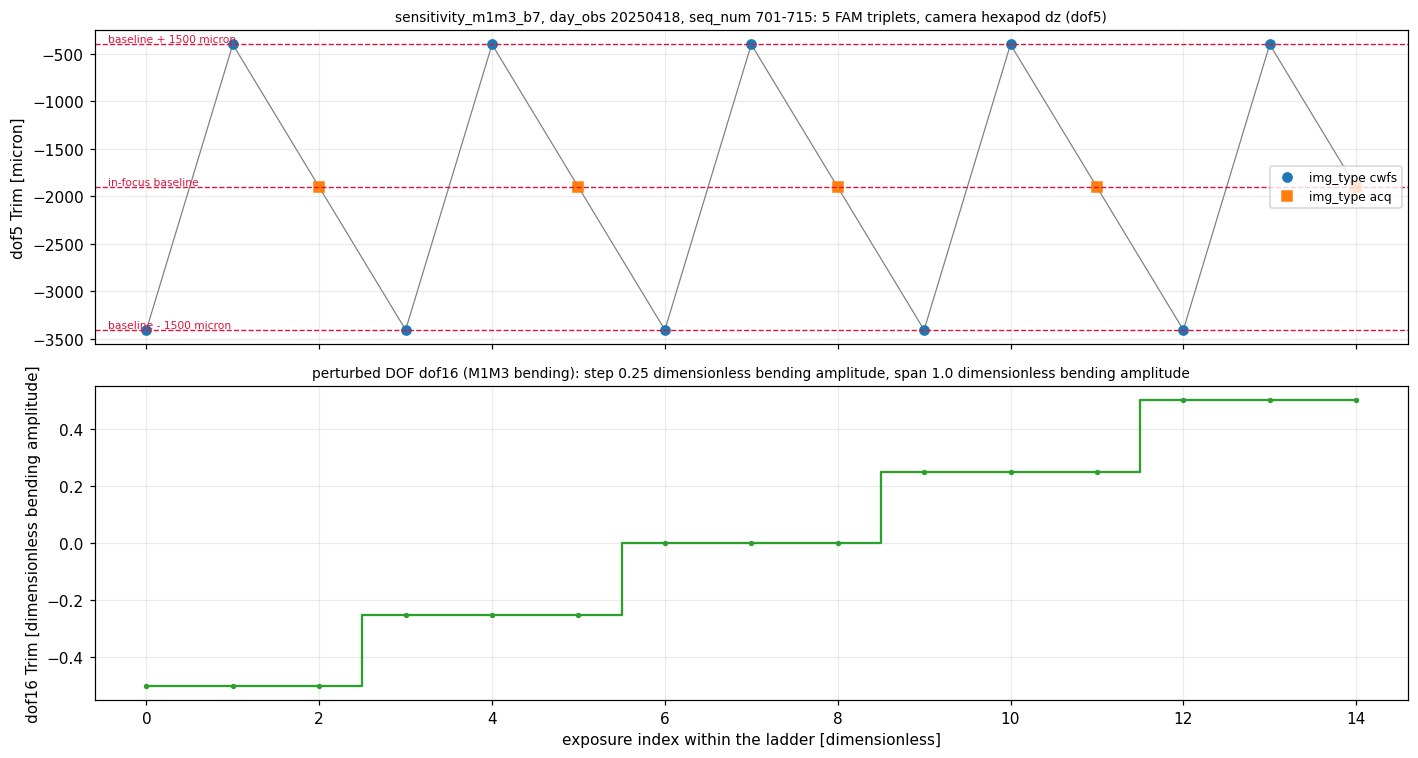

In [22]:
# Worked example: one ladder, exposure by exposure, showing both levels of structure.
# Top: dof5 saw-tooth, one triplet per step. Bottom: the perturbed DOF staircase.
EXAMPLE_REASON = "sensitivity_m1m3_b7"

cand = ladders[(ladders["reason"] == EXAMPLE_REASON) & (ladders["n_triplets"] == 5)]
if cand.empty:
    print(f"{EXAMPLE_REASON} has no five-triplet ladder; "
          f"available: {sorted(set(ladders['reason']))}")
else:
    row = cand.iloc[0]
    g = obs[(obs["ladder"] == row["ladder"])
            & obs["triplet"].isin(tri.index)].sort_values(["day_obs", "seq_num"])
    w = row["dof_moved"]
    x = np.arange(len(g))
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

    # dof5: the intra/extra/in-focus saw-tooth that defines the triplets.
    for kind, mark in [("cwfs", "o"), ("acq", "s")]:
        s = g["img_type"] == kind
        axes[0].plot(x[s.to_numpy()], g.loc[s, "dof5"], mark, ms=6, label=f"img_type {kind}")
    axes[0].plot(x, g["dof5"], color="grey", lw=0.8, zorder=0)
    focus = tri.loc[g["triplet"].unique(), "dz_focus"].mean()
    for lvl, lab in [(focus, "in-focus baseline"),
                     (focus - FAM_DZ_SPAN_UM / 2, "baseline - 1500 micron"),
                     (focus + FAM_DZ_SPAN_UM / 2, "baseline + 1500 micron")]:
        axes[0].axhline(lvl, color="crimson", ls="--", lw=0.9)
        # Label inside the axes, above the line, so it neither overlaps the legend on
        # the right nor is clipped by the figure edge.
        axes[0].text(0.01, lvl, lab, fontsize=7, va="bottom", ha="left", color="crimson",
                     transform=axes[0].get_yaxis_transform())
    axes[0].set_xlim(-0.6, len(g) - 0.4)
    axes[0].set_ylabel("dof5 Trim [micron]")
    axes[0].set_title(f"{EXAMPLE_REASON}, day_obs {row['day_obs']}, "
                      f"seq_num {row['seq_range']}: "
                      f"{row['n_triplets']} FAM triplets, camera hexapod dz (dof5)",
                      fontsize=9)
    axes[0].legend(fontsize=8, loc="center right")
    axes[0].grid(alpha=0.25)

    # The perturbed DOF: one constant value per triplet, stepping uniformly.
    axes[1].step(x, g[w].to_numpy(float), where="mid", color="C2", lw=1.5)
    axes[1].plot(x, g[w].to_numpy(float), ".", color="C2", ms=5)
    unit = "micron" if int(w[3:]) < 10 else "dimensionless bending amplitude"
    axes[1].set_ylabel(f"{w} Trim [{unit}]")
    axes[1].set_xlabel("exposure index within the ladder [dimensionless]")
    axes[1].set_title(f"perturbed DOF {w} ({row['dof_group']}): step "
                      f"{row['step']} {unit}, span {row['span']} {unit}", fontsize=9)
    axes[1].grid(alpha=0.25)
    fig.tight_layout()

    print(f"ladder key: {row['ladder']}   block: {row['block']}")
    print(f"day_obs {row['day_obs']}, seq_num {row['seq_range']} inclusive")
    print(f"{w} Trim value per triplet: {row['values']}")
    print(f"uniform step: {row['uniform_step']}")
    print(f"exposures in the ladder: {len(g)} "
          f"({int((g['img_type'] == 'cwfs').sum())} cwfs, "
          f"{int((g['img_type'] == 'acq').sum())} acq)")

block -> DOF perturbed, from the ladders:
  BLOCK-T377       4 ladders  camera hexapod                       day_obs 20250421
                  dof6-dof9
  BLOCK-T378       1 ladders  M2 hexapod                           day_obs 20250513
                  dof0
  BLOCK-T378_0     5 ladders  M1M3 bending                         day_obs 20250417 to 20250419
                  dof10-dof14
  BLOCK-T378_1     8 ladders  M1M3 bending                         day_obs 20250418 to 20250527
                  dof15-dof19
  BLOCK-T378_2     4 ladders  M1M3 bending                         day_obs 20250421 to 20250423
                  dof20-dof21, dof23-dof24
  BLOCK-T378_3     7 ladders  M1M3 bending                         day_obs 20250424 to 20250513
                  dof25-dof29
  BLOCK-T379_0     6 ladders  M2 bending                           day_obs 20250417
                  dof30-dof34
  BLOCK-T379_1     5 ladders  M2 bending                           day_obs 20250420
                  dof35-

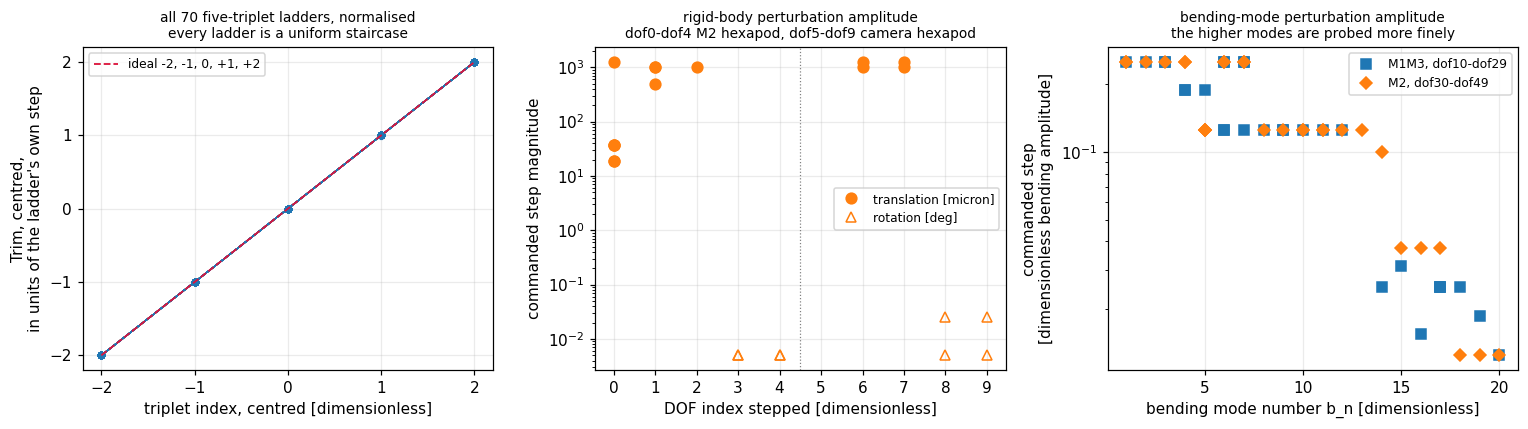

In [23]:
# Every ladder at once. Left: each ladder centred on its own midpoint and divided by its
# own step, so ladders in micron and in dimensionless bending amplitude share one axis --
# all of them should collapse onto the same -2, -1, 0, +1, +2 line. Middle and right: the
# step size actually commanded, which that normalisation deliberately divides out. The two
# are on separate panels rather than twin axes because their units are not comparable.
five = ladders[ladders["n_triplets"] == 5]
idx = ladders["dof_moved"].str[3:].astype(int)
is_rigid = idx < 10

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for r in five.itertuples():
    v = np.asarray(r.values, float)
    axes[0].plot(np.arange(len(v)) - 2, (v - np.median(v)) / r.step, "o-",
                 ms=4, lw=0.8, alpha=0.35, color="C0")
axes[0].plot([-2, 2], [-2, 2], color="crimson", lw=1.2, ls="--",
             label="ideal -2, -1, 0, +1, +2")
axes[0].set_xlabel("triplet index, centred [dimensionless]")
axes[0].set_ylabel("Trim, centred,\nin units of the ladder's own step")
axes[0].set_title(f"all {len(five)} five-triplet ladders, normalised\n"
                  "every ladder is a uniform staircase", fontsize=9)
axes[0].set_xticks([-2, -1, 0, 1, 2])
axes[0].set_yticks([-2, -1, 0, 1, 2])
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(alpha=0.25)

# Rigid body: dof0-dof9, translations in micron and rotations in deg, so the two are
# separated by marker rather than mixed on one scale.
DZXY = {0, 1, 2, 5, 6, 7}          # dz, dx, dy of each hexapod: micron
sel = ladders[is_rigid]
for keep, mark, lab in [(True, "o", "translation [micron]"),
                        (False, "^", "rotation [deg]")]:
    s = sel[sel["dof_moved"].str[3:].astype(int).isin(DZXY) == keep]
    if len(s):
        axes[1].semilogy(s["dof_moved"].str[3:].astype(int), s["step"].abs(),
                         mark, ms=7, color="C1", fillstyle="none" if not keep else "full",
                         label=lab)
axes[1].set_xlabel("DOF index stepped [dimensionless]")
axes[1].set_ylabel("commanded step magnitude")
axes[1].set_title("rigid-body perturbation amplitude\n"
                  "dof0-dof4 M2 hexapod, dof5-dof9 camera hexapod", fontsize=9)
axes[1].axvline(4.5, color="grey", lw=0.8, ls=":")
axes[1].set_xticks(range(0, 10))
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

# Bending modes: one common unit, so mirror and mode number are the only variables.
sel = ladders[~is_rigid]
for lo, mark, lab in [(10, "s", "M1M3, dof10-dof29"), (30, "D", "M2, dof30-dof49")]:
    s = sel[(sel["dof_moved"].str[3:].astype(int) >= lo)
            & (sel["dof_moved"].str[3:].astype(int) < lo + 20)]
    axes[2].semilogy(s["dof_moved"].str[3:].astype(int) - lo + 1, s["step"].abs(),
                     mark, ms=6, label=lab)
axes[2].set_xlabel("bending mode number b_n [dimensionless]")
axes[2].set_ylabel("commanded step\n[dimensionless bending amplitude]")
axes[2].set_title("bending-mode perturbation amplitude\n"
                  "the higher modes are probed more finely", fontsize=9)
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

fig.tight_layout()


def dof_index_summary(dof_names):
    """Compact description of a set of DOF indices, collapsing only runs.

    Parameters
    ----------
    dof_names : `set` [`str`]
        DOF column names, ``"dof<i>"``.

    Returns
    -------
    text : `str`
        Consecutive indices as ``dofA-dofB``, non-consecutive ones listed separately and
        comma-joined.

    Notes
    -----
    A plain minimum-to-maximum range would misdescribe the repeatability block, which
    samples a scattered subset of the 50 DOF rather than a contiguous run: written as a
    range its four M1M3 modes and its M2 hexapod dz would imply 41 DOF it never touched.
    """
    idx = sorted(int(n[3:]) for n in dof_names)
    runs = []
    for i in idx:
        if runs and i == runs[-1][1] + 1:
            runs[-1][1] = i
        else:
            runs.append([i, i])
    return ", ".join(f"dof{a}" if a == b else f"dof{a}-dof{b}" for a, b in runs)


# Which DOF each block perturbed, gathered from its ladders.
print("block -> DOF perturbed, from the ladders:")
for block, g in ladders.groupby("block"):
    nights = sorted(set(g["day_obs"]))
    print(f"  {block:14s} {len(g):3d} ladders  "
          f"{', '.join(sorted(set(g['dof_group']))):36s} "
          f"day_obs {nights[0]}"
          + (f" to {nights[-1]}" if len(nights) > 1 else "")
          + f"\n{'':18s}{dof_index_summary(set(g['dof_moved']))}")

<a id='summary'></a>
## 8. Summary

In [24]:
print(f"database: {DB_PATH}\n")
print(q("""
    SELECT COUNT(*) AS exposures, COUNT(DISTINCT day_obs) AS nights,
           MIN(day_obs) AS first_day_obs, MAX(day_obs) AS last_day_obs
    FROM visit_telemetry
""").to_string(index=False))

print("\nFour things to carry away:")
print("  1. Read units and completeness from column_coverage, not from the column name.")
print(f"  2. Turbulence columns are NaN before day_obs {TURB_START_DAY_OBS}, and")
print("     optical_state spans fewer nights than visit_telemetry: both silently")
print("     shrink a join instead of raising.")
print("  3. For a commanded perturbation sequence use Trim (dof0-dof49), which shows the")
print("     ladder directly as a staircase; use Tweak for per-event closed-loop steps.")
print("  4. The FAM observing pattern is what makes a perturbation identifiable: a")
print("     triplet is a dof5 span of 3000 micron about the local in-focus baseline, and")
print("     a ladder is five triplets stepping one other DOF uniformly.")

print("\nSensitivity-matrix result:")
print(f"  blocks matched: {', '.join(sorted(set(ladders['block'])))}")
print(f"  {len(tri)} FAM triplets, {len(ladders)} ladders, "
      f"{int(ladders['uniform_step'].sum())} of {len(ladders)} with a uniform step")
print(f"  distinct DOF perturbed: {ladders['dof_moved'].nunique()} of 50; "
      f"{len(multi)} of them measured by more than one ladder")

# The cross-check is commanded Trim against the ConsDB observation_reason annotation --
# no look-up table, no fit, no wavefront.
if bend["offset"].nunique() == 1:
    print(f"  all {len(bend)} bending-mode ladders at one index offset of "
          f"{int(bend['offset'].iloc[0])} (dimensionless)")
else:
    _modal = int(bend["offset"].mode().iloc[0])
    _odd = bend[bend["offset"] != _modal]
    print(f"  bending-mode ladders at the modal index offset of {_modal} "
          f"(dimensionless): {len(bend) - len(_odd)} of {len(bend)}")
    for r in _odd.itertuples():
        print(f"    {r.reason} on day_obs {r.day_obs} seq_num {r.seq_range} landed on "
              f"{r.dof_moved} ({dof_group_name(int(r.dof_moved[3:]))}), "
              f"offset {r.offset} (dimensionless)")

n_bad = int((~rigid["agrees"]).sum())
print(f"  rigid-body ladders matching the ts_ofc ordering: "
      f"{int(rigid['agrees'].sum())} of {len(rigid)}")
if n_bad:
    nights = sorted(set(rigid.loc[~rigid["agrees"], "day_obs"]))
    shifts = sorted(set(rigid.loc[~rigid["agrees"], "shift"]))
    print(f"  {n_bad} disagree, on day_obs {nights}, at DOF index shift "
          f"{shifts} (dimensionless) -- see section 7")

con.close()
print("\nconnection closed")

database: /sdf/group/rubin/u/roodman/LSST/notebooks/rubin-work/value_added/output/aos_efd.duckdb

 exposures  nights  first_day_obs  last_day_obs
    213704     366       20250415      20260714

Four things to carry away:
  1. Read units and completeness from column_coverage, not from the column name.
  2. Turbulence columns are NaN before day_obs 20251102, and
     optical_state spans fewer nights than visit_telemetry: both silently
     shrink a join instead of raising.
  3. For a commanded perturbation sequence use Trim (dof0-dof49), which shows the
     ladder directly as a staircase; use Tweak for per-event closed-loop steps.
  4. The FAM observing pattern is what makes a perturbation identifiable: a
     triplet is a dof5 span of 3000 micron about the local in-focus baseline, and
     a ladder is five triplets stepping one other DOF uniformly.

Sensitivity-matrix result:
  blocks matched: BLOCK-T377, BLOCK-T378, BLOCK-T378_0, BLOCK-T378_1, BLOCK-T378_2, BLOCK-T378_3, BLOCK-T379_0